<h2 align="center">AtliQo Bank Credit Card Launch: Phase 1</h2>

Objective: Analyze customers' transactions and credit profiles to figure out a target group for the launch of AtliQo bank credit card

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

### Data Import

In [82]:
df_cust = pd.read_csv('dataset/customers.csv')
df_cp = pd.read_csv('dataset/credit_profiles.csv')
df_trans = pd.read_csv('dataset/transactions.csv')

<h3 style="color:blue" align="center">Explore Customers Table<h1>

In [3]:
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married


In [4]:
df_cust.shape

(1000, 8)

In [5]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,950.000000
mean,500.500000,36.405000,139410.314737
std,288.819436,15.666155,112416.802007
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,47627.500000
50%,500.500000,32.000000,112218.500000
75%,750.250000,46.000000,193137.500000
max,1000.000000,135.000000,449346.000000


Outliers :
- In the above output we annual income min as 2$ which can be an outlier
- Also minimium age is 1 could also be outlier

In [6]:
df_cust.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cust_id         1000 non-null   int64  
 1   name            1000 non-null   str    
 2   gender          1000 non-null   str    
 3   age             1000 non-null   int64  
 4   location        1000 non-null   str    
 5   occupation      1000 non-null   str    
 6   annual_income   950 non-null    float64
 7   marital_status  1000 non-null   str    
dtypes: float64(1), int64(2), str(5)
memory usage: 62.6 KB


From the above output we can see annual income has null values, we have to handle them before doing further analysis

<h4 style="color:Purple">1. Analyze Income Column<h2>

### Handle Null Values: Annual income

Now let us check if any of our dataframe columns contain null values

In [7]:
df_cust.isnull().sum()

cust_id            0
name               0
gender             0
age                0
location           0
occupation         0
annual_income     50
marital_status     0
dtype: int64

In [8]:
print(df_cust[df_cust.annual_income.isnull()].shape[0])
df_cust[df_cust.annual_income.isnull()].head(10)

50


,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Isha Arora,Female,25,Rural,Artist,NaN,Married
82,83,Sanjana Singhal,Male,27,City,Freelancer,NaN,Single
97,98,Sia Batra,Male,47,Suburb,Business Owner,NaN,Married
102,103,Pooja Ganguly,Male,32,City,Data Scientist,NaN,Married
155,156,Krishna Trivedi,Male,24,City,Fullstack Developer,NaN,Married
170,171,Advait Kulkarni,Male,52,City,Business Owner,NaN,Single
186,187,Aanya Pande,Male,53,City,Consultant,NaN,Single
192,193,Mira Naidu,Male,37,Suburb,Data Scientist,NaN,Married
227,228,Mihika Batra,Male,48,City,Business Owner,NaN,Married
232,233,Aaditya Rathore,Male,26,City,Freelancer,NaN,Married


We can handle these null values using different ways,

1. **Remove them**: Since there are 50 of them in a dataframe of 1000, we will not remove them as we don't want to loose some important records
1. **Replace them with mean or median**: It is suggested with use median in the case of income. This is because in an income data there could be outliers and median is more robust to these outliers
1. **Replace them with median per occupation**: Occupation wise median income can vary. It is best to use a median per occupation for replacement

In [9]:
# Occupation wise median

median_per_occ = df_cust.groupby('occupation')['annual_income'].median()
median_per_occ

occupation
Accountant              65265.0
Artist                  45794.0
Business Owner         261191.5
Consultant              58017.0
Data Scientist         135759.0
Freelancer              46759.0
Fullstack Developer     76774.0
Name: annual_income, dtype: float64

In [10]:
df_cust['annual_income'] = df_cust['annual_income'] \
                          .fillna(df_cust['occupation'].map(median_per_occ))
                        

In [11]:
print(df_cust[df_cust.annual_income.isnull()].shape[0])
df_cust[df_cust.annual_income.isnull()].head(10)

0


,cust_id,name,gender,age,location,occupation,annual_income,marital_status


In [12]:
df_cust.iloc[[14,102,192,232]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Isha Arora,Female,25,Rural,Artist,45794.0,Married
102,103,Pooja Ganguly,Male,32,City,Data Scientist,135759.0,Married
192,193,Mira Naidu,Male,37,Suburb,Data Scientist,135759.0,Married
232,233,Aaditya Rathore,Male,26,City,Freelancer,46759.0,Married


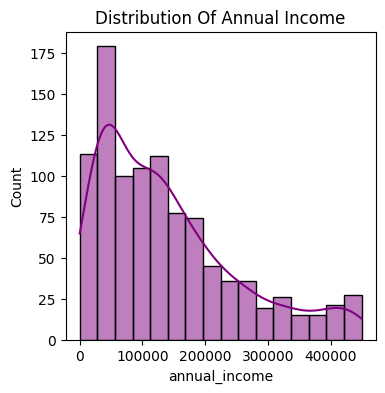

In [13]:
# Distribution of Annual Income
plt.figure(figsize=(4,4))
sns.histplot(df_cust.annual_income,kde=True,color='purple',label='data')
plt.title('Distribution Of Annual Income')
plt.show()

### Handling Outliers : Annual Income

High incomes for business owners are expected and will be kept as-is to reflect realistic variation in the dataset.

On the lower end, the minimum income observed is 2.

For this project, we will assume that annual income should be at least 100.

Any values below 100 will be treated as outliers, likely due to data entry errors.

These flagged outliers can be corrected or removed before further analysis.

In [14]:
print(df_cust[df_cust['annual_income'] < 100].shape)
df_cust[df_cust['annual_income'] < 100]

(10, 8)


,cust_id,name,gender,age,location,occupation,annual_income,marital_status
31,32,Veer Gambhir,Male,50,City,Business Owner,50.0,Married
262,263,Veer Rathod,Male,53,Suburb,Business Owner,50.0,Married
316,317,Avinash Chauhan,Male,47,City,Consultant,50.0,Married
333,334,Samaira D'Souza,Female,29,City,Data Scientist,50.0,Married
340,341,Ridhi Rastogi,Female,33,Rural,Fullstack Developer,50.0,Married
543,544,Gauri Gupta,Male,54,City,Consultant,2.0,Married
592,593,Vivaan Pande,Female,32,City,Business Owner,50.0,Married
633,634,Aradhya Pandey,Male,26,City,Data Scientist,2.0,Married
686,687,Gauri Nanda,Male,40,City,Business Owner,2.0,Married
696,697,Avani Lalwani,Male,47,City,Consultant,20.0,Married


Above records (with <100$ income) are outliers. We have following options to treat them,

1. **Remove them**: we decided not to remove them as these are valid customers and we want to include them in our analysis
2. **Replace them with mean or median** : Mean is sensitive to outliers. It is better to use median for income values
3. **Replace them with occupation wise median**: Income level may vary based on occupation. For example median income for data scientist can be different from a median income of a business owner. It is better to use occupation wise median income for replacement


In [15]:
# Replace Annual Income < 100 with occupation median
df_cust.loc[df_cust['annual_income'] < 100, 'annual_income'] = (
    df_cust.loc[df_cust['annual_income'] < 100, 'occupation']
      .map(median_per_occ)
)


In [16]:
print(df_cust[df_cust['annual_income'] < 100].shape)
df_cust[df_cust['annual_income'] < 100]

(0, 8)


,cust_id,name,gender,age,location,occupation,annual_income,marital_status


In [17]:
df_cust.iloc[[333,633]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
333,334,Samaira D'Souza,Female,29,City,Data Scientist,135759.0,Married
633,634,Aradhya Pandey,Male,26,City,Data Scientist,135759.0,Married


### Data Visualization: Annual Income

We will explore average income level based on occupation, gender, location and marital status

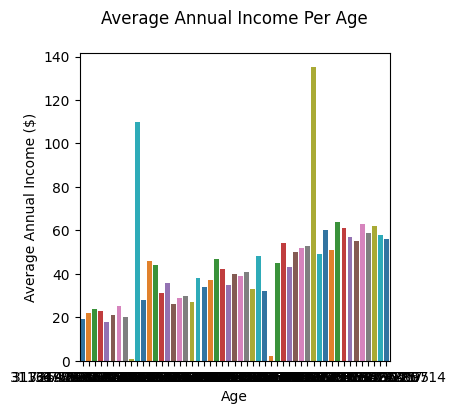

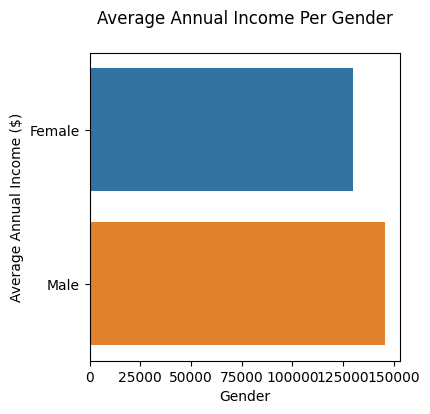

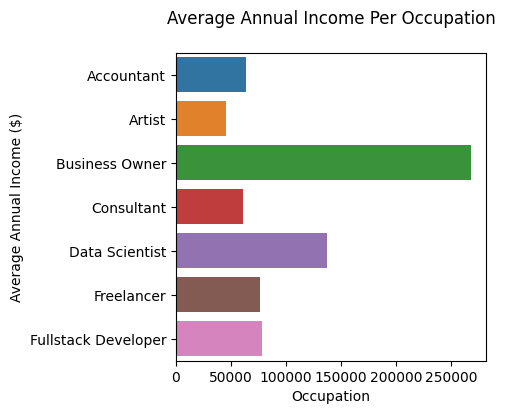

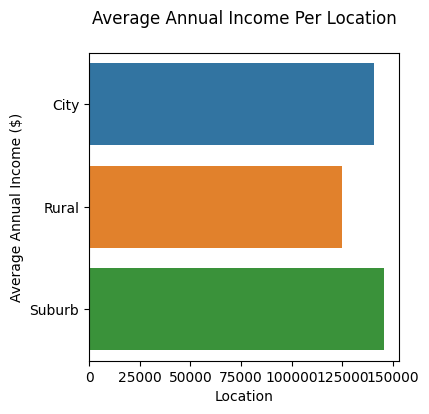

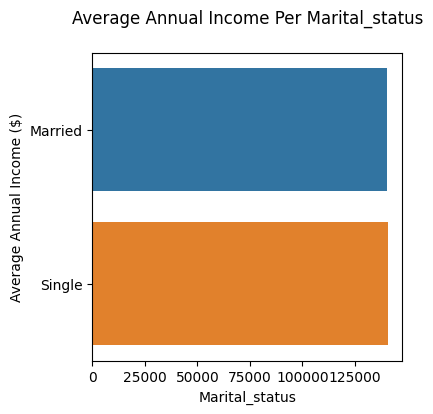

In [18]:
category = ['age','gender','occupation','location','marital_status']
for col in category:
    plt.figure(figsize=(4,4))
    avg_income_per_group = df_cust.groupby(col)['annual_income'].mean()
    sns.barplot(x=avg_income_per_group.values, y=avg_income_per_group.index,palette='tab10')
    plt.title(f'Average Annual Income Per {col.capitalize()}\n')
    plt.xlabel(col.capitalize())
    plt.ylabel('Average Annual Income ($)')
    plt.show()

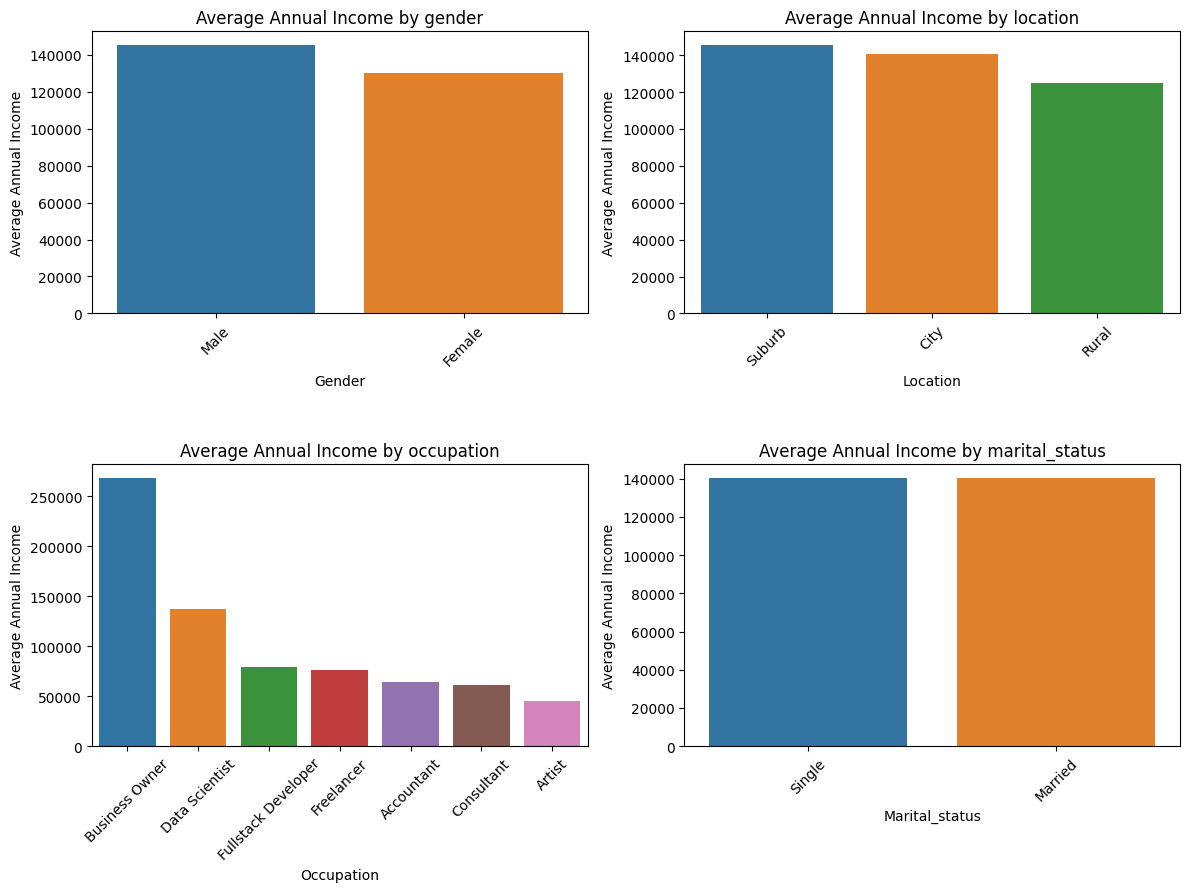

In [19]:
# List of categorical columns
cat_cols = ['gender', 'location', 'occupation', 'marital_status']

num_rows = 3
# Create subplots
fig, axes = plt.subplots(num_rows, 2, figsize=(12, 4 * num_rows))

# Flatten the axes array to make it easier to iterate
axes = axes.flatten()

# Create subplots for each categorical column
for i, cat_col in enumerate(cat_cols):
    # Calculate the average annual income for each category
    avg_income_by_category = df_cust.groupby(cat_col)['annual_income'].mean().reset_index()
    
    # Sort the data by 'annual_income' before plotting
    sorted_data = avg_income_by_category.sort_values(by='annual_income', ascending=False)
    
    sns.barplot(x=cat_col, y='annual_income', data=sorted_data, ci=None, ax=axes[i], palette='tab10')
    axes[i].set_title(f'Average Annual Income by {cat_col}')
    axes[i].set_xlabel(cat_col.capitalize())
    axes[i].set_ylabel('Average Annual Income')

    # Rotate x-axis labels for better readability
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

# Hide any unused subplots
for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])
plt.tight_layout()
plt.show()

<h4 style="color:Purple">2. Analyze Age Column<h2>

In [20]:
df_cust.age.max(), df_cust.age.min()

(np.int64(135), np.int64(1))

They seem to be outliers hence we plot box chart to understand better

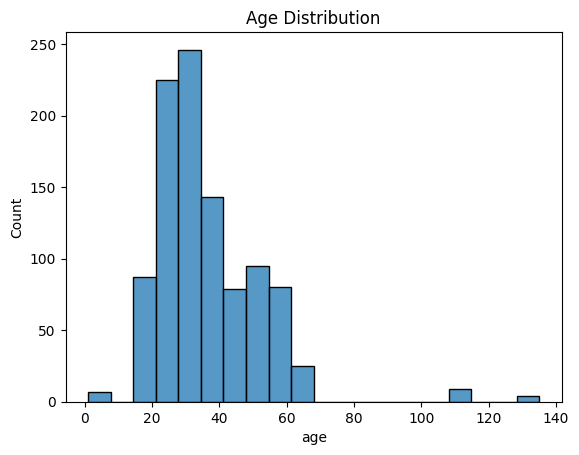

In [21]:
sns.histplot(x=df_cust.age,bins=20)
plt.title('Age Distribution')
plt.show()


From above we will try to find out all customers above 80 and below 15.

In [22]:
# Outliers detection

print(df_cust[(df_cust.age < 15) | (df_cust.age > 80)].shape[0])
df_cust.loc[(df_cust.age < 15) | (df_cust.age > 80),'occupation']


20


0           Business Owner
41                  Artist
165             Freelancer
174             Freelancer
222             Freelancer
277             Consultant
295             Accountant
325             Accountant
610         Business Owner
692         Business Owner
703             Freelancer
709         Data Scientist
728         Business Owner
832    Fullstack Developer
845             Consultant
855    Fullstack Developer
895             Freelancer
923             Freelancer
951         Data Scientist
991    Fullstack Developer
Name: occupation, dtype: str

In [23]:
median_age_per_occupation = df_cust.groupby('occupation')['age'].median().astype(int)
median_age_per_occupation

occupation
Accountant             31
Artist                 26
Business Owner         51
Consultant             46
Data Scientist         32
Freelancer             24
Fullstack Developer    27
Name: age, dtype: int64

We will calculate median per occupation and then use that for replacing outliers

In [24]:
df_cust.loc[(df_cust.age < 15) | (df_cust.age > 80),'age'] = (
    df_cust.loc[
        (df_cust.age < 15) | (df_cust.age > 80),'occupation'
        ].map(median_age_per_occupation)
)

In [25]:
print(df_cust[(df_cust.age < 15) | (df_cust.age > 80)].shape[0])
df_cust.loc[(df_cust.age < 15) | (df_cust.age > 80),'occupation']

0


Series([], Name: occupation, dtype: str)

In [26]:
df_cust.age.describe()

count    1000.000000
mean       35.539000
std        12.277998
min        18.000000
25%        26.000000
50%        32.000000
75%        44.250000
max        64.000000
Name: age, dtype: float64

### Data Visualization : Age Column

In [27]:
# Creating age groups
bins = [17,25,48,65]
labels = ['18-25','26-48','49-65'] # bins are (17,25], (25,48], (48,65]
df_cust['age_group'] = pd.cut(df_cust['age'],bins=bins,labels=labels)

In [28]:
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group
0,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married,49-65
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single,26-48
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married,18-25
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married,18-25
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married,26-48


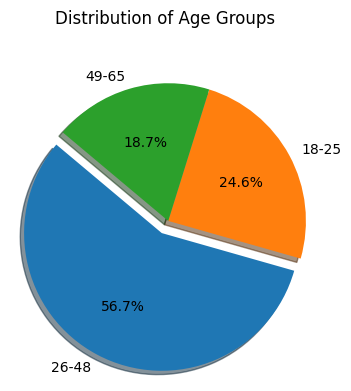

In [29]:
# Calculate the count of values in each age group
age_group_counts = df_cust['age_group'].value_counts(normalize=True) * 100

# Plot the pie chart
plt.figure(figsize=(4, 4))
plt.pie(
    age_group_counts, 
    labels=age_group_counts.index, 
    explode=(0.1,0,0), 
    autopct='%1.1f%%', 
    shadow=True,
    startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Distribution of Age Groups\n\n')
plt.show()

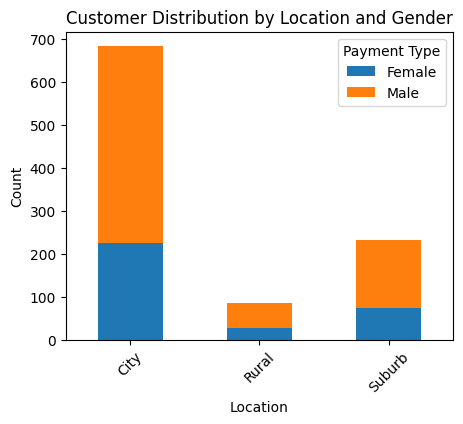

In [30]:
customer_location_gender = df_cust.groupby(['location', 'gender']).size().unstack(fill_value=0)

# Create a stacked bar chart to visualize the distribution of payment types for each occupation
customer_location_gender.plot(kind='bar', stacked=True, figsize=(5, 4))

# Add labels and title
plt.xlabel('Location')
plt.ylabel('Count')
plt.title('Customer Distribution by Location and Gender')

# Show the bar chart
plt.legend(title='Payment Type', bbox_to_anchor=(1, 1))  # Add a legend

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45)

plt.show()

<h3 style="color:blue" align="center">Explore Credit Profile Table<h1>

In [31]:
df_cp.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


In [32]:
df_cp.shape

(1004, 6)

### Data Cleaning : Removing Duplicates

There are 1004 rows in this dataframe whereas customers dataframe had only 1000. There might be invalid or duplicate data in df_cp

In [33]:
df_cp[df_cp.duplicated('cust_id', keep=False)]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
516,517,308,NaN,NaN,NaN,NaN
517,517,308,0.113860,33.0,3.0,500.0
569,569,344,NaN,NaN,NaN,NaN
570,569,344,0.112599,37.0,0.0,500.0
607,606,734,NaN,NaN,NaN,NaN
608,606,734,0.193418,4392.0,1.0,40000.0
664,662,442,NaN,NaN,NaN,NaN
665,662,442,0.856039,266.0,2.0,500.0


In [34]:
df_cp.drop_duplicates(subset='cust_id', keep='last',inplace=True)
df_cp = df_cp.reset_index()

In [35]:
print(df_cp.shape[0])
df_cp[df_cp.duplicated('cust_id', keep=False)]

1000


,index,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit


In [36]:
df_cp.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   index                           1000 non-null   int64  
 1   cust_id                         1000 non-null   int64  
 2   credit_score                    1000 non-null   int64  
 3   credit_utilisation              1000 non-null   float64
 4   outstanding_debt                1000 non-null   float64
 5   credit_inquiries_last_6_months  1000 non-null   float64
 6   credit_limit                    935 non-null    float64
dtypes: float64(4), int64(3)
memory usage: 54.8 KB


We can see there are null value for credit limit , which has to be handled

When we observe min and max for various columns, we realize that outstanding_debt's max is greater than the max of credit_limit. Based on the business understanding, we know that the maximum debt that a customer can have is equal to credit limit. They would not be allowed to spend more than their credit limit. 

In [37]:
df_cp.describe()

,index,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,935.000000
mean,501.150000,500.500000,589.182000,0.498950,9683.597000,1.955000,19235.561497
std,290.480995,288.819436,152.284929,0.233139,25255.893671,1.414559,24489.997195
min,0.000000,1.000000,300.000000,0.103761,33.000000,0.000000,500.000000
25%,249.750000,250.750000,460.000000,0.293917,221.000000,1.000000,750.000000
50%,499.500000,500.500000,601.500000,0.487422,550.000000,2.000000,1250.000000
75%,753.250000,750.250000,738.000000,0.697829,11819.500000,3.000000,40000.000000
max,1003.000000,1000.000000,799.000000,0.899648,209901.000000,4.000000,60000.000000


### Handle Null Values: Credit Limit

In [38]:
df_cp.credit_limit.isnull().sum()

np.int64(65)

In [39]:
df_cp[df_cp.credit_limit.isnull()]

,index,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
10,10,11,679,0.557450,9187.0,2.0,NaN
35,35,36,790,0.112535,4261.0,1.0,NaN
37,37,38,514,0.296971,238.0,2.0,NaN
45,45,46,761,0.596041,24234.0,2.0,NaN
64,64,65,734,0.473715,13631.0,0.0,NaN
...,...,...,...,...,...,...,...
908,912,909,479,0.487555,320.0,3.0,NaN
927,931,928,311,0.832244,316.0,2.0,NaN
944,948,945,526,0.272734,227.0,1.0,NaN
950,954,951,513,0.175914,131.0,3.0,NaN


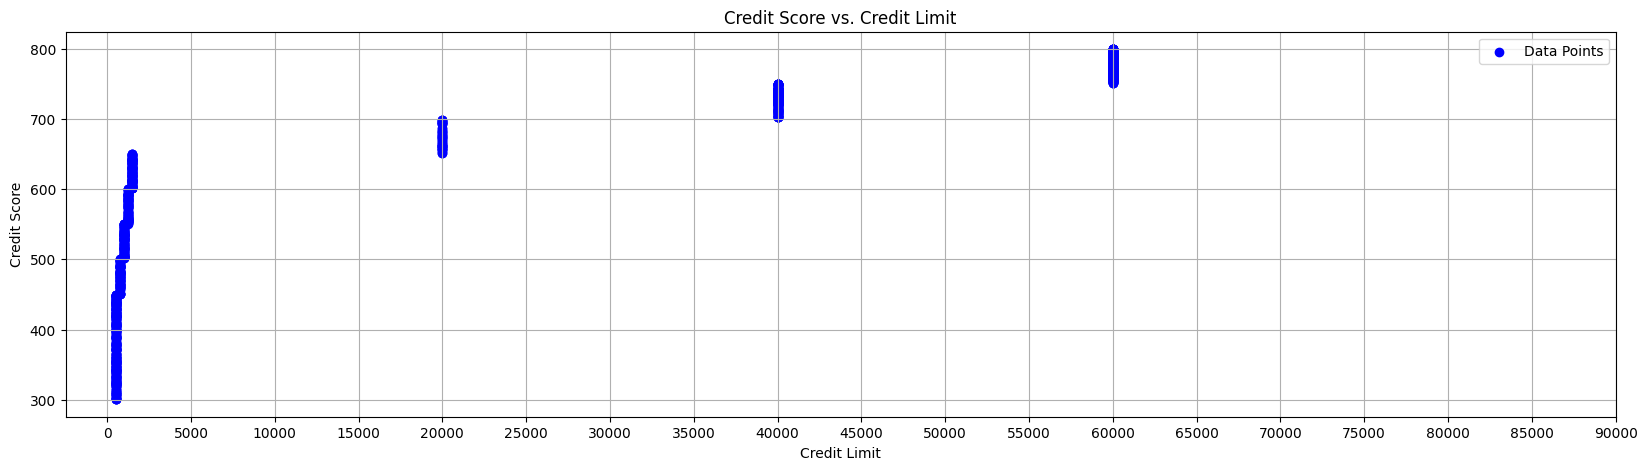

In [40]:
# Looking at scatter plot for credit score vs credit_limit
# Create a scatter plot
plt.figure(figsize=(20, 5))
plt.scatter(df_cp['credit_limit'], df_cp['credit_score'], c='blue', marker='o', label='Data Points')

# Customize the plot
plt.title('Credit Score vs. Credit Limit')
plt.xlabel('Credit Limit')
plt.ylabel('Credit Score')

# Adjust the y-axis bin interval to 1000
plt.xticks(range(0, 90001, 5000))
plt.grid(True)

# Show the plot
plt.legend()
plt.show()

Here we can see clear relationship between credit score and credit limit. Where there are levels for example, upto 650 score is getting a very minor credit limit (<1000$) where as a score between 650 to 700 is getting around 20000. Score between 700 to 750 is getting around 40K etc.

In [41]:
# Creating credit range column
bin_ranges = [299, 450, 500, 550, 600, 650, 700, 750, 800] # bins are (299-459],(459-499] and so on..
range_labels = [f'{start}-{end-1}' for start,end in zip(bin_ranges,bin_ranges[1:])]
df_cp['credit_range'] = pd.cut(df_cp.credit_score,bins=bin_ranges,labels=range_labels)

In [42]:
df_cp.head()

,index,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_range
0,0,1,749,0.585171,19571.0,0.0,40000.0,700-749
1,1,2,587,0.107928,161644.0,2.0,1250.0,550-599
2,2,3,544,0.854807,513.0,4.0,1000.0,500-549
3,3,4,504,0.336938,224.0,2.0,1000.0,500-549
4,4,5,708,0.586151,18090.0,2.0,40000.0,700-749


We can use MODE function to find out most frequently occuring credit limit for a given score range.

In [43]:
credit_limit_mode = df_cp.groupby('credit_range')['credit_limit'].agg(lambda x : x.mode())
credit_limit_mode


credit_range
299-449      500.0
450-499      750.0
500-549     1000.0
550-599     1250.0
600-649     1500.0
650-699    20000.0
700-749    40000.0
750-799    60000.0
Name: credit_limit, dtype: float64

In [44]:
df_cp['credit_limit'] = df_cp['credit_limit'].fillna(
    df_cp['credit_range'].map(credit_limit_mode)
)

In [45]:
df_cp.credit_limit.isnull().sum()

np.int64(0)

In [46]:
df_cp[df_cp.credit_limit.isnull()]


,index,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_range


### Handle Outliers : Outstanding_debt

Text(0.5, 1.0, 'Box plot for outstanding debt')

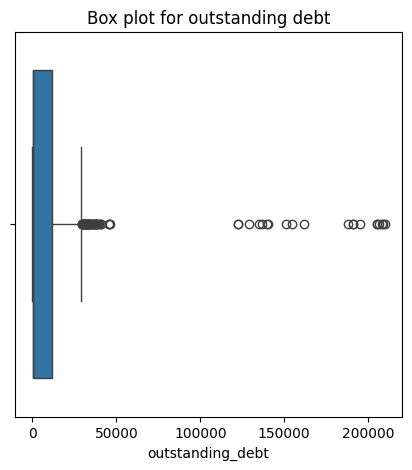

In [47]:
# Visualising Outliers

plt.figure(figsize=(5, 5))
sns.boxplot(x=df_cp['outstanding_debt'])
plt.title('Box plot for outstanding debt')

Instead of using any statistical approach (such as standard deviation or IQR), here too we will use a business knowledge. 
- We will mark any outstanding debt that is greater than credit limit as an outlier.
- We will replace these outliers with credit limit

In [48]:
print(df_cp[df_cp['outstanding_debt'] > df_cp['credit_limit']].shape[0])
df_cp[df_cp['outstanding_debt'] > df_cp['credit_limit']]

20


,index,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_range
1,1,2,587,0.107928,161644.0,2.0,1250.0,550-599
19,19,20,647,0.439132,205014.0,3.0,1500.0,600-649
25,25,26,758,0.250811,190838.0,2.0,60000.0,750-799
38,38,39,734,0.573023,122758.0,3.0,40000.0,700-749
93,93,94,737,0.739948,137058.0,2.0,40000.0,700-749
204,204,205,303,0.364360,187849.0,0.0,500.0,299-449
271,271,272,703,0.446886,154568.0,1.0,40000.0,700-749
301,301,302,722,0.608076,122402.0,4.0,40000.0,700-749
330,330,331,799,0.363420,208898.0,4.0,60000.0,750-799
350,350,351,320,0.285081,150860.0,0.0,500.0,299-449


In [49]:
df_cp.loc[df_cp['outstanding_debt'] > df_cp['credit_limit'], 'outstanding_debt'] = (
    df_cp.loc[df_cp['outstanding_debt'] > df_cp['credit_limit'], 'credit_limit']
)


In [50]:
df_cp[df_cp['outstanding_debt'] > df_cp['credit_limit']]

,index,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_range


In [51]:
df_cp.iloc[[204,446,545]]

,index,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_range
204,204,205,303,0.364360,500.0,0.0,500.0,299-449
446,446,447,754,0.178394,60000.0,2.0,60000.0,750-799
545,546,546,309,0.484459,145.0,1.0,500.0,299-449


### Data Exploration: Visualizing Correlation in Credit Score Table

In [52]:
df_merged = df_cust.merge(df_cp, on='cust_id', how='inner')
df_merged.head(2)

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,index,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_range
0,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married,49-65,0,749,0.585171,19571.0,0.0,40000.0,700-749
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single,26-48,1,587,0.107928,1250.0,2.0,1250.0,550-599


In [53]:
numerical_cols = ['credit_score', 'credit_utilisation', 'outstanding_debt', 'credit_limit', 'annual_income','age']

correlation_matrix = df_merged[numerical_cols].corr()
correlation_matrix

,credit_score,credit_utilisation,outstanding_debt,credit_limit,annual_income,age
credit_score,1.000000,-0.070445,0.680654,0.847951,0.575751,0.444961
credit_utilisation,-0.070445,1.000000,0.192838,-0.080504,-0.086368,-0.027828
outstanding_debt,0.680654,0.192838,1.000000,0.810581,0.555661,0.444375
credit_limit,0.847951,-0.080504,0.810581,1.000000,0.684780,0.511078
annual_income,0.575751,-0.086368,0.555661,0.684780,1.000000,0.619103
age,0.444961,-0.027828,0.444375,0.511078,0.619103,1.000000


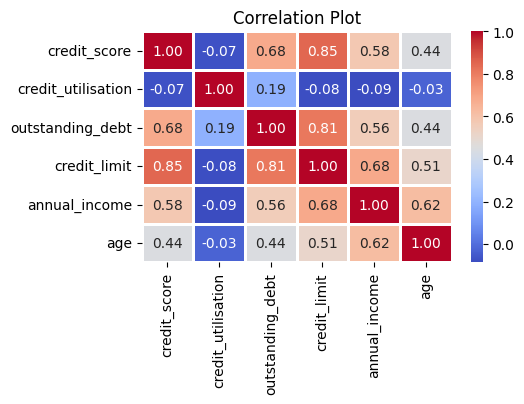

In [54]:
# Create a heatmap of the correlation matrix
plt.figure(figsize=(5, 3))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.8)
plt.title('Correlation Plot')
plt.show()

<h3 style="color:blue" align="center">Explore Transactions Table<h1>

In [55]:
print(df_trans.shape)
df_trans.head()

(500000, 7)


,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


In [56]:
df_trans.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   tran_id           500000 non-null  int64
 1   cust_id           500000 non-null  int64
 2   tran_date         500000 non-null  str  
 3   tran_amount       500000 non-null  int64
 4   platform          495059 non-null  str  
 5   product_category  500000 non-null  str  
 6   payment_type      500000 non-null  str  
dtypes: int64(3), str(4)
memory usage: 26.7 MB


In [57]:
df_trans.isnull().sum()

tran_id                0
cust_id                0
tran_date              0
tran_amount            0
platform            4941
product_category       0
payment_type           0
dtype: int64

In [58]:
df_trans.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.00000
mean,250000.500000,501.400428,3225.20733
std,144337.711635,288.641924,13098.74276
min,1.000000,1.000000,0.00000
25%,125000.750000,252.000000,64.00000
50%,250000.500000,502.000000,141.00000
75%,375000.250000,752.000000,397.00000
max,500000.000000,1000.000000,69999.00000


We can see that trans amount have outliers as trans amount cannot be 0 and also maximum value is too high

### Handling Null Values : Platform

In [59]:
df_trans[df_trans['platform'].isnull()]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
355,356,58,2023-01-01,237,NaN,Electronics,Net Banking
418,419,383,2023-01-01,338,NaN,Electronics,Credit Card
607,608,421,2023-01-01,700,NaN,Electronics,Phonepe
844,845,945,2023-01-01,493,NaN,Sports,Credit Card
912,913,384,2023-01-01,85,NaN,Fashion & Apparel,Phonepe
...,...,...,...,...,...,...,...
499579,499580,924,2023-09-05,31,NaN,Fashion & Apparel,Gpay
499646,499647,944,2023-09-05,58445,NaN,Fashion & Apparel,Phonepe
499725,499726,620,2023-09-05,15,NaN,Sports,Net Banking
499833,499834,616,2023-09-05,97,NaN,Fashion & Apparel,Credit Card


<Axes: xlabel='count', ylabel='product_category'>

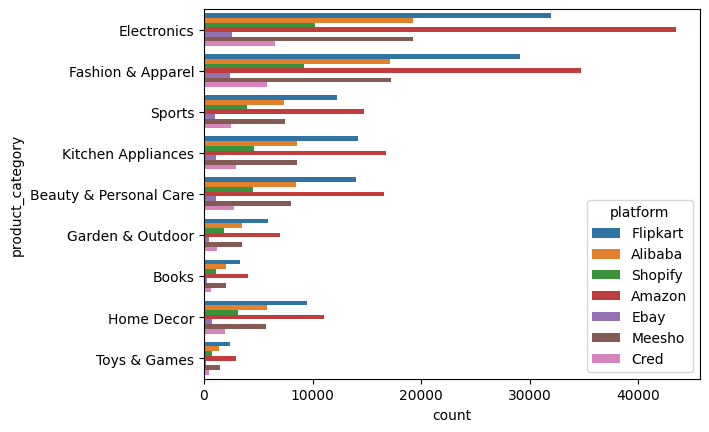

In [60]:
sns.countplot(y='product_category',hue='platform',data=df_trans)

In the above chart, you can see that in all product categories Amazon is the platform that is used the most for making purchases. For handling null values in platform may be we can just replace them using "Amazon" as a product platform just because it is used most frequently

In [61]:
df_trans.platform.mode()[0]

'Amazon'

In [62]:
df_trans['platform'].dtype

<StringDtype(storage='python', na_value=nan)>

In [63]:
df_trans['platform'] = df_trans['platform'].fillna(df_trans['platform'].mode()[0])

In [64]:
df_trans.isnull().sum()

tran_id             0
cust_id             0
tran_date           0
tran_amount         0
platform            0
product_category    0
payment_type        0
dtype: int64

### Handling Outliers : Transaction Amount

In [83]:
df_trans['tran_amount'].describe()

count    500000.00000
mean       3225.20733
std       13098.74276
min           0.00000
25%          64.00000
50%         141.00000
75%         397.00000
max       69999.00000
Name: tran_amount, dtype: float64

In [84]:
df_trans[df_trans['tran_amount'] <=0]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
120,121,440,2023-01-01,0,Amazon,Electronics,Credit Card
141,142,839,2023-01-01,0,Amazon,Electronics,Credit Card
517,518,147,2023-01-01,0,Amazon,Electronics,Credit Card
533,534,891,2023-01-01,0,Amazon,Electronics,Credit Card
586,587,108,2023-01-01,0,Amazon,Electronics,Credit Card
...,...,...,...,...,...,...,...
499326,499327,695,2023-09-05,0,Amazon,Electronics,Credit Card
499494,499495,295,2023-09-05,0,Amazon,Electronics,Credit Card
499708,499709,141,2023-09-05,0,Amazon,Electronics,Credit Card
499928,499929,4,2023-09-05,0,Amazon,Electronics,Credit Card


In [85]:
df_trans[df_trans['tran_amount'] <=0]['product_category'].value_counts() 

product_category
Electronics    4734
Name: count, dtype: int64

In [86]:
df_trans[df_trans['tran_amount'] <=0]['payment_type'].value_counts()

payment_type
Credit Card    4734
Name: count, dtype: int64

In [87]:
df_trans[df_trans['tran_amount'] <=0]['platform'].value_counts()

platform
Amazon    4734
Name: count, dtype: int64

It appears that all these zero transactions occur when 
- platform=Amazon,
- product_category=Eletronics and
- payment_type=Credit Card,

Therefore, We need to find its median to replace these zero values. 
We are not using mean because as these 0 values will affect the mean.

In [88]:
median_to_replace = df_trans[df_trans.tran_amount>0].tran_amount.median()
median_to_replace

np.float64(143.0)

In [89]:
df_trans['tran_amount'] = df_trans['tran_amount'].replace(0,median_to_replace)

In [90]:
df_trans[df_trans.tran_amount==0]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type


<Axes: xlabel='tran_amount', ylabel='Count'>

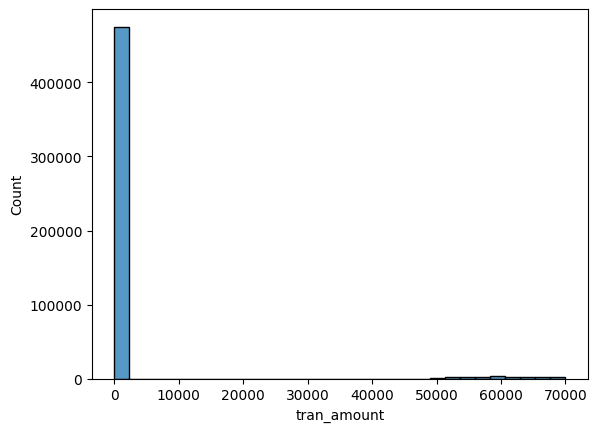

In [93]:
sns.histplot(x='tran_amount', data=df_trans, bins=30)

In [94]:
df_trans.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.000000
mean,250000.500000,501.400428,3226.561254
std,144337.711635,288.641924,13098.416709
min,1.000000,1.000000,2.000000
25%,125000.750000,252.000000,66.000000
50%,250000.500000,502.000000,143.000000
75%,375000.250000,752.000000,397.000000
max,500000.000000,1000.000000,69999.000000


In [98]:
df_trans['tran_amount'].quantile(0.90)

np.float64(798.0)

As we observed that 90% of data has transaction amount less than 1000$, hence transition amount over 50000$ is definetly an outlier.
We will use IQR to set the upper limit and treat rest as outliers.

In [100]:
q1,q3 = df_trans['tran_amount'].quantile([0.25,0.75])
iqr = q3 - q1
upper = q3 + 2 * iqr
upper

1059.0

In [101]:
df_trans[df_trans.tran_amount<upper].tran_amount.max()

np.int64(999)

In [102]:
df_trans[df_trans.tran_amount > upper]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,61963,Shopify,Beauty & Personal Care,Credit Card
49,50,287,2023-01-01,57869,Amazon,Toys & Games,Gpay
94,95,770,2023-01-01,52881,Ebay,Kitchen Appliances,Credit Card
104,105,549,2023-01-01,58574,Flipkart,Fashion & Apparel,Gpay
113,114,790,2023-01-01,51669,Shopify,Kitchen Appliances,Credit Card
...,...,...,...,...,...,...,...
499742,499743,868,2023-09-05,55131,Meesho,Fashion & Apparel,Gpay
499888,499889,614,2023-09-05,59679,Meesho,Fashion & Apparel,Net Banking
499900,499901,811,2023-09-05,60184,Flipkart,Sports,Debit Card
499966,499967,662,2023-09-05,54678,Meesho,Sports,Gpay


Above records (with 999$ transaction amount) are outliers. We have following options to treat them,

1. **Remove them**: we decided not to remove them as these are too many records
3. **Replace them with occupation wise mean**: Expense level may vary based on product category.It is better to use product category wise mean transaction amount for replacement


In [107]:
mean_per_product = df_trans[df_trans.tran_amount <= upper].groupby('product_category')['tran_amount'].mean().astype(int)
mean_per_product

# We have to calculate mean excluding the outliers

product_category
Beauty & Personal Care     92
Books                      29
Electronics               494
Fashion & Apparel          64
Garden & Outdoor          125
Home Decor                302
Kitchen Appliances        176
Sports                    269
Toys & Games               50
Name: tran_amount, dtype: int64

In [108]:
df_trans.loc[df_trans.tran_amount > upper,'tran_amount'] = (
    df_trans.loc[df_trans.tran_amount > upper,'product_category'].map(mean_per_product)
)

In [109]:
df_trans[df_trans.tran_amount > upper]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type


In [110]:
df_trans.iloc[[94,113,499900,499996]]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
94,95,770,2023-01-01,176,Ebay,Kitchen Appliances,Credit Card
113,114,790,2023-01-01,176,Shopify,Kitchen Appliances,Credit Card
499900,499901,811,2023-09-05,269,Flipkart,Sports,Debit Card
499996,499997,569,2023-09-05,64,Meesho,Fashion & Apparel,Net Banking


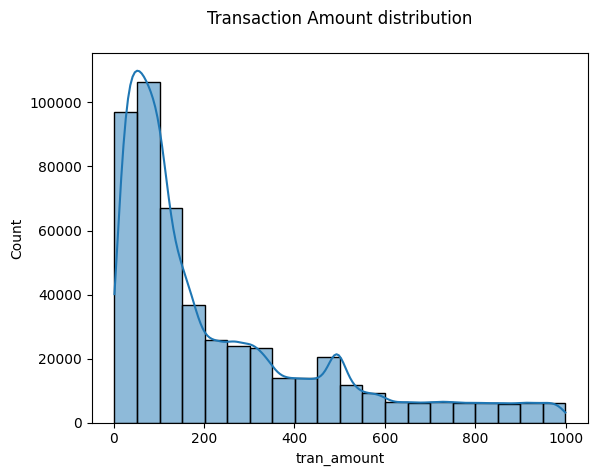

In [112]:
sns.histplot(x='tran_amount', data=df_trans, bins=20, kde=True)
plt.title('Transaction Amount distribution\n')
plt.show()

Above shows the histogram of transactions after the removal of outliers. You can see that distribution is right skewed. Transaction amount now is less than 1000

### Data Visualization: Payment Type Distribution

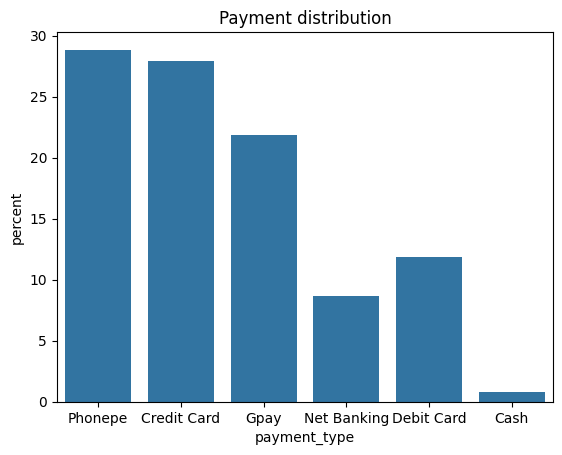

In [114]:
sns.countplot(x=df_trans.payment_type, stat='percent')
plt.title('Payment distribution')
plt.show()

**Distribution of payment types across age groups**

In [123]:
df_merged_2 = pd.merge(
    df_merged[['cust_id','marital_status','annual_income','age_group','credit_limit','outstanding_debt','credit_range']],
    df_trans[['cust_id','tran_id','tran_amount','product_category','platform','payment_type']],
    on='cust_id',
    how='inner')
df_merged_2.head()

,cust_id,marital_status,annual_income,age_group,credit_limit,outstanding_debt,credit_range,tran_id,tran_amount,product_category,platform,payment_type
0,1,Married,358211.0,49-65,40000.0,19571.0,700-749,1283,30,Fashion & Apparel,Shopify,Net Banking
1,1,Married,358211.0,49-65,40000.0,19571.0,700-749,1382,96,Sports,Amazon,Debit Card
2,1,Married,358211.0,49-65,40000.0,19571.0,700-749,1521,86,Garden & Outdoor,Meesho,Gpay
3,1,Married,358211.0,49-65,40000.0,19571.0,700-749,1576,149,Beauty & Personal Care,Amazon,Phonepe
4,1,Married,358211.0,49-65,40000.0,19571.0,700-749,1757,37,Fashion & Apparel,Flipkart,Credit Card


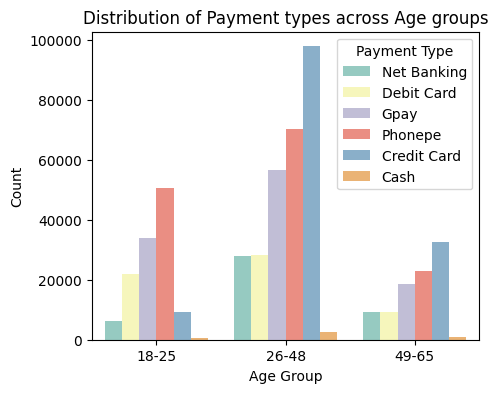

In [124]:
plt.figure(figsize=(5, 4))
sns.countplot(x='age_group', hue='payment_type', data=df_merged_2, palette='Set3')
plt.title('Distribution of Payment types across Age groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Payment Type', loc='upper right')

plt.show()

From above analysis, we can see that age group 18-25 has less exposure to credit cards compared to other groups

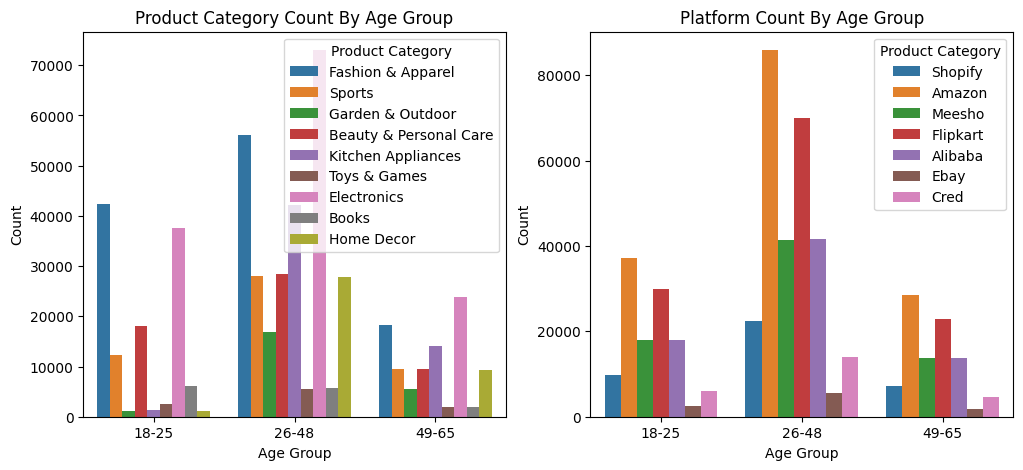

In [125]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))

sns.countplot(x='age_group', hue="product_category", data=df_merged_2, ax=ax1)
ax1.set_title("Product Category Count By Age Group")
ax1.set_xlabel("Age Group")
ax1.set_ylabel("Count")
ax1.legend(title="Product Category", loc='upper right')

sns.countplot(x='age_group', hue="platform", data=df_merged_2, ax=ax2)
ax2.set_title("Platform Count By Age Group")
ax2.set_xlabel("Age Group")
ax2.set_ylabel("Count")
ax2.legend(title="Product Category", loc='upper right')

plt.show()

### Observations:

1. Top 3 purchasing categories of customers in age group (18 -25) : Electronics, Fashion & Apparel, Beauty & personal care
1. Top platforms : Amazon, Flipkart, Alibaba

### Data Visualization: Average Transaction Amount

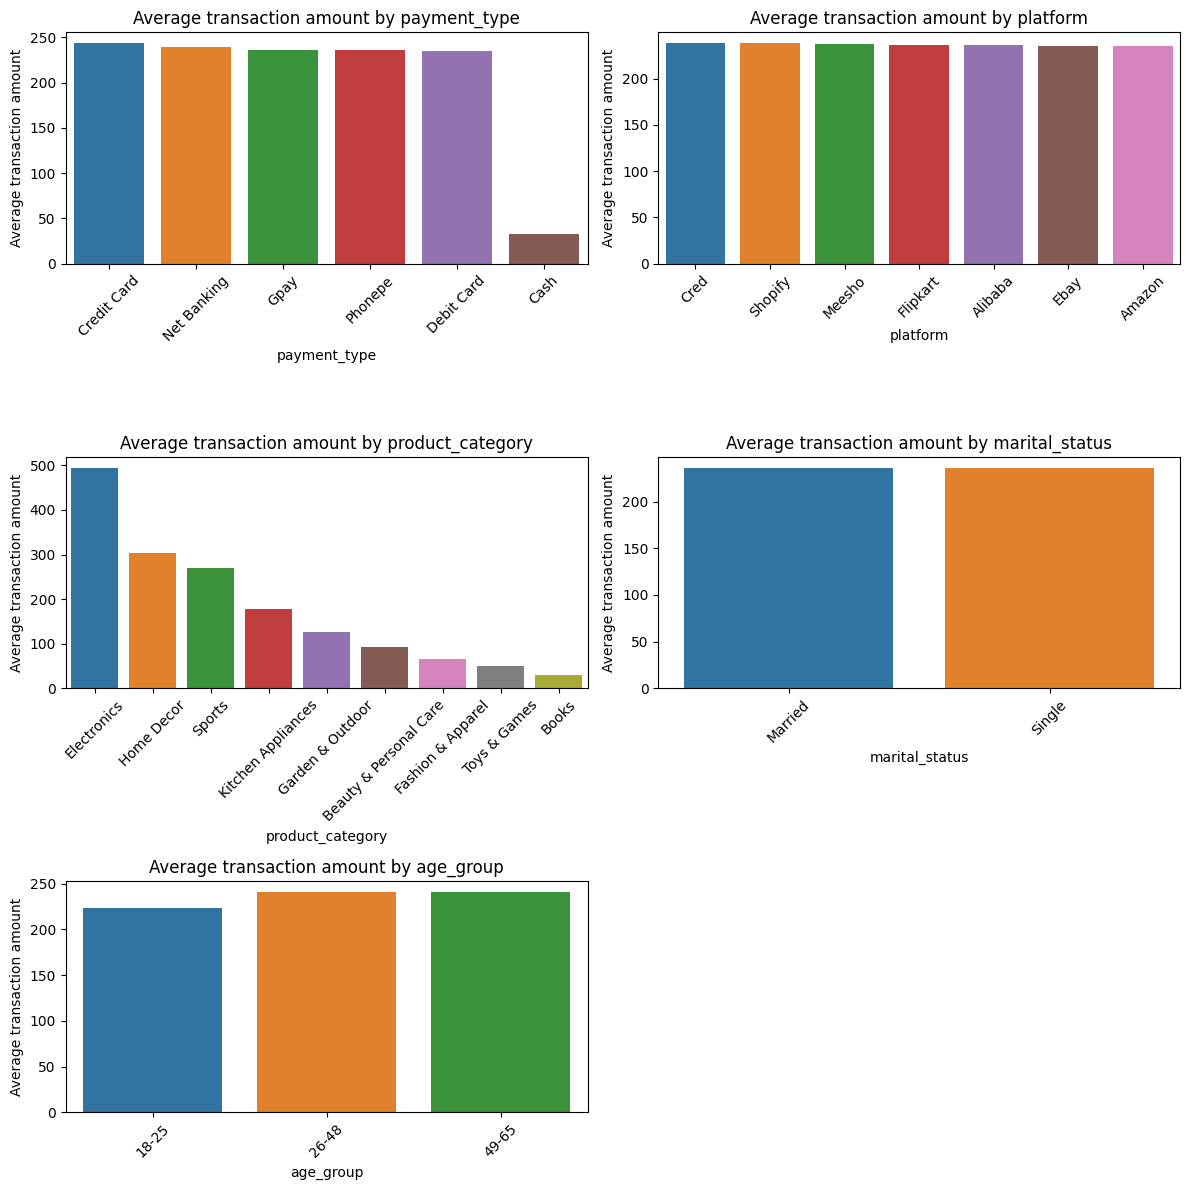

In [126]:
# List of categorical columns
cat_cols = ['payment_type', 'platform', 'product_category', 'marital_status', 'age_group']

num_rows = 3
# Create subplots
fig, axes = plt.subplots(num_rows, 2, figsize=(12, 4 * num_rows))

# Flatten the axes array to make it easier to iterate
axes = axes.flatten()

# Create subplots for each categorical column
for i, cat_col in enumerate(cat_cols):
    # Calculate the average annual income for each category
    avg_tran_amount_by_category = df_merged_2.groupby(cat_col)['tran_amount'].mean().reset_index()
    
    # Sort the data by 'annual_income' before plotting
    sorted_data = avg_tran_amount_by_category.sort_values(by='tran_amount', ascending=False)
    
    sns.barplot(x=cat_col, y='tran_amount', data=sorted_data, ci=None, ax=axes[i], palette='tab10')
    axes[i].set_title(f'Average transaction amount by {cat_col}')
    axes[i].set_xlabel(cat_col)
    axes[i].set_ylabel('Average transaction amount')

    # Rotate x-axis labels for better readability
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

# Hide any unused subplots
for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])
plt.tight_layout()
plt.show()

### Further Analysis On Age Group

Let us do further analysis on age group to figure out their average income, credit limit, credit score etc

In [128]:
# Group the data by age group and calculate the average credit_limit and credit_score
age_group_metrics = df_merged.groupby('age_group')[['annual_income', 'credit_limit', 'credit_score']].mean().reset_index()
age_group_metrics

,age_group,annual_income,credit_limit,credit_score
0,18-25,37091.235772,1130.081301,484.451220
1,26-48,145869.623457,20560.405644,597.569665
2,49-65,260165.925134,41699.197861,701.524064


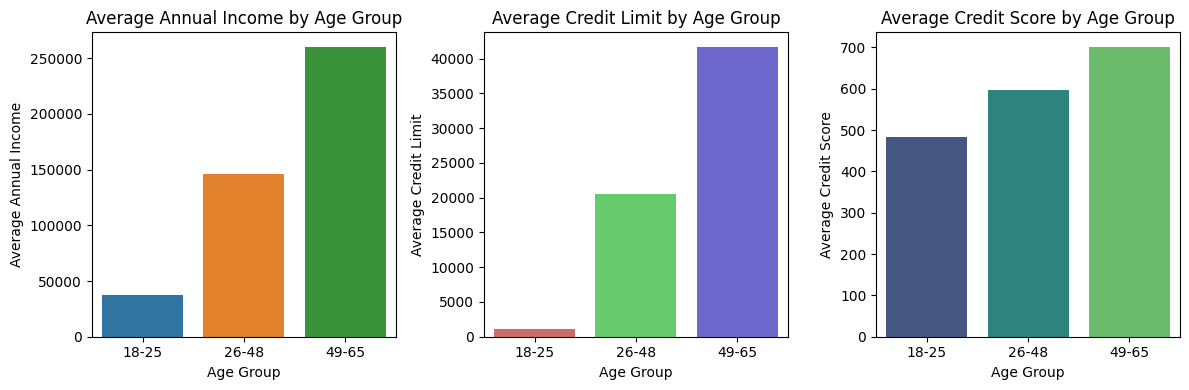

In [129]:
# Create subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

# Plot 1: Average annual income by age group
sns.barplot(x='age_group', y='annual_income', data=age_group_metrics, palette='tab10', ax=ax1)
ax1.set_title('Average Annual Income by Age Group')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Average Annual Income')
ax1.tick_params(axis='x', rotation=0)

# Plot 2: Average Max Credit Limit by Age Group
sns.barplot(x='age_group', y='credit_limit', data=age_group_metrics, palette='hls', ax=ax2)
ax2.set_title('Average Credit Limit by Age Group')
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Average Credit Limit')
ax2.tick_params(axis='x', rotation=0)

# Plot 3: Average Credit Score by Age Group
sns.barplot(x='age_group', y='credit_score', data=age_group_metrics, palette='viridis', ax=ax3)
ax3.set_title('Average Credit Score by Age Group')
ax3.set_xlabel('Age Group')
ax3.set_ylabel('Average Credit Score')
ax3.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

<h3 align="center", style="color:purple">Finalize Target Market For a Trial Credit Card Launch<h3>

<center><img src="images/analysis.png" alt="Credit Card Launch Analysis" width="700" /></center>

1. People with age group of 18 -25 accounts to ~26% of customer base in the data
2. Avg annual income of this group is less than 50k
3. They don't have much credit history which is getting reflected in their credit score and credit limit 
4. Usage of credit cards as payment type is relatively low compared to other groups
5. Top 3 most shopping products categories : Electronics, Fashion & Apparel, Beauty & Personal care